In [1]:
import pandas as pd

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

In [3]:
survey = pd.read_csv("with_features.csv")

In [4]:
survey.shape

(49123, 151)

In [10]:
survey.head(1)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseChoice,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformChoice,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeChoice,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AIAgentImpactSomewhat agree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIHuman,AIOpen,ConvertedCompYearly,JobSat,num_languages,num_databases,num_platforms,num_frameworks,experience_group,salary_bucket,has_degree,log_salary,remote,is_fulltime,ai_usage_score,seniority,is_manager,tech_diversity,db_specialist,polyglot,web_developer
0,1,i am a developer by profession,25-34 years old,"master’s degree (m.a., m.s., m.eng., mba, etc.)",employed,"caring for dependents (children, elderly, etc.)",8.0,"yes, i am not new to coding but am learning new coding techniques or programming language",online courses or certification (includes all media types);other online resources (e.g. standard...,"yes, i learned how to use ai-enabled tools for my personal curiosity and/or hobbies",ai codegen tools or ai-enabled apps,14.0,"developer, mobile",20 to 99 employees,people manager,remote,"yes, i influenced the purchase of a substantial addition to the tech stack",work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,fintech,3.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,i'm not sure,i have neither consider or transitioned into a new career or industry,7.0,3.0,ukraine,eur european euro,52800.0,yes,bash/shell (all shells);dart;sql,dart,dart,yes,cloud firestore;postgresql,NaN,NaN,yes,amazon web services (aws);cloudflare;firebase;google cloud;gradle,NaN,NaN,no,NaN,NaN,NaN,yes,android studio;notepad++;visual studio;visual studio code;xcode,NaN,NaN,NaN,NaN,NaN,windows;macos;android,windows;macos;android;ios;ipados,confluence;github;gitlab;jira;markdown file,markdown file,markdown file,"stack overflow;reddit;github (public projects, not private repos);youtube;linkedin;medium",NaN,NaN,yes,openai gpt (chatbot models);openai image generating models;openai reasoning models,NaN,NaN,yes,a few times per week,between 5 and 10 years,i have never participated in q&a on stack overflow,NaN,1.0,NaN,6.0,2.0,3.0,7.0,8.0,9.0,11.0,15.0,neutral,"rarely, alm

## Clustering

In [22]:
cluster_features = [
    "YearsCode",
    "num_languages",
    "num_databases",
    "num_platforms",
    "num_frameworks",
    "ai_usage_score",
    "ConvertedCompYearly"
]

In [23]:
cluster_df = survey[cluster_features].copy()

cluster_df.head()

,YearsCode,num_languages,num_databases,num_platforms,num_frameworks,ai_usage_score,ConvertedCompYearly
0,14.0,3,2,5,0,2.0,61256.0
1,10.0,1,2,7,1,3.0,104413.0
2,12.0,4,3,4,3,4.0,53061.0
3,5.0,3,0,2,1,3.0,36197.0
4,22.0,14,7,9,5,3.0,60000.0


In [24]:
survey['AISelect'].value_counts()

AISelect
yes, i use ai tools daily                      15863
unknown                                        15437
yes, i use ai tools weekly                      5951
no, and i don't plan to                         5453
yes, i use ai tools monthly or infrequently     4624
no, but i plan to soon                          1795
Name: count, dtype: int64

In [25]:
mapping = {
    "no, and i don't plan to":0,
    "no, but i plan to soon ":1,
    "yes, i use ai tools monthly or infrequently":2,
    "yes, i use ai tools weekly":3,
    "yes, i use ai tools daily":4
}

survey["ai_usage_score"] = survey["AISelect"].map(mapping)

In [46]:
cluster_df.isna().sum()

YearsCode              0
num_languages          0
num_databases          0
num_platforms          0
num_frameworks         0
ai_usage_score         0
ConvertedCompYearly    0
dtype: int64

In [43]:
cluster_df['ai_usage_score'] = cluster_df['ai_usage_score'].fillna(cluster_df['ai_usage_score'].median())

In [45]:
cluster_df['ConvertedCompYearly'] = cluster_df['ConvertedCompYearly'].fillna(cluster_df['ConvertedCompYearly'].median())

In [35]:
cluster_df['ConvertedCompYearly'].unique()

array([ 61256., 104413.,  53061., ...,    829., 167954.,  15379.],
      shape=(6235,))

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df)

In [48]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

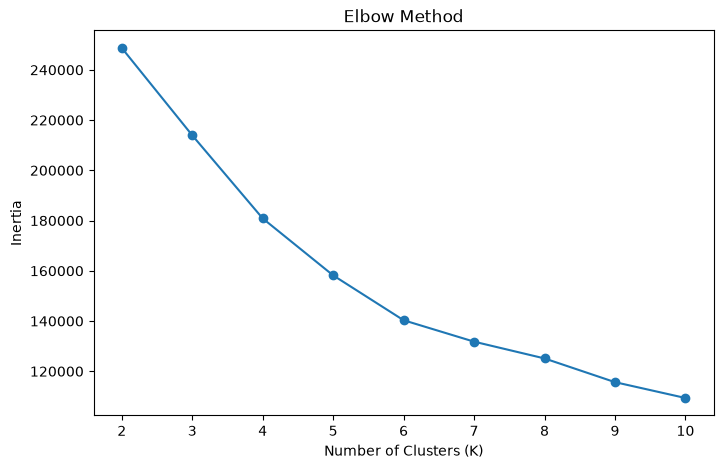

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [50]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [51]:
survey["developer_cluster"] = clusters

In [52]:
survey["developer_cluster"].value_counts()

developer_cluster
0    22602
1    15499
2     5998
3     5022
4        2
Name: count, dtype: int64

In [55]:
cluster_profile = survey.groupby(
    "developer_cluster"
)[cluster_features].mean()

cluster_profile

,YearsCode,num_languages,num_databases,num_platforms,num_frameworks,ai_usage_score,ConvertedCompYearly
developer_cluster,,,,,,,
0,14.032563,0.832847,0.192726,0.292496,0.143439,3.337628,8.419540e+04
1,17.125944,6.094522,2.758823,5.482805,2.694174,3.502449,9.872644e+04
2,22.257586,5.473491,1.754918,3.322608,1.404468,0.248158,1.114087e+05
3,16.392075,9.614496,6.445042,12.233174,6.663879,3.380555,1.029794e+05
4,18.500000,2.500000,2.000000,3.500000,2.000000,4.000000,4.177636e+07


## Recommendation System

In [5]:
tech_cols = [
    "LanguageHaveWorkedWith",
    "DatabaseHaveWorkedWith",
    "WebframeHaveWorkedWith",
    "PlatformHaveWorkedWith",
    "DevEnvsHaveWorkedWith",
    "AIModelsHaveWorkedWith"
]

survey[tech_cols].head()

,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,WebframeHaveWorkedWith,PlatformHaveWorkedWith,DevEnvsHaveWorkedWith,AIModelsHaveWorkedWith
0,bash/shell (all shells);dart;sql,cloud firestore;postgresql,NaN,amazon web services (aws);cloudflare;firebase;google cloud;gradle,android studio;notepad++;visual studio;visual studio code;xcode,openai gpt (chatbot models);openai image generating models;openai reasoning models
1,java,dynamodb;mongodb,spring boot,amazon web services (aws);datadog;docker;homebrew;kubernetes;maven (build tool);terraform,intellij idea;pycharm;visual studio code;xcode,openai gpt (chatbot models)
2,dart;html/css;javascript;typescript,mongodb;mysql;postgresql,next.js;node.js;react,datadog;firebase;npm;pnpm,visual studio code,gemini (flash general purpose models);openai gpt (chatbot models)
3,java;kotlin;sql,NaN,spring boot,amazon web services (aws);google cloud,NaN,NaN
4,c;c#;c++;delphi;html/css;java;javascript;lua;powershell;python;sql;typescript;vba;visual basic (...,elasticsearch;microsoft sql server;mysql;oracle;postgresql;redis;sqlite,angular;asp.net;asp.net core;flask;jquery,amazon web services (aws);apt;docker;make;maven (build tool);msbuild;npm;nuget;pip,eclipse;intellij idea;jupyter notebook/jupyterlab;notepad++;pycharm;rider;visual studio;webstorm,openai gpt (chatbot models)


In [9]:
[col for col in tech_cols if col in survey.columns]  # Checking if columns exist in dataframe

['LanguageHaveWorkedWith',
 'DatabaseHaveWorkedWith',
 'WebframeHaveWorkedWith',
 'PlatformHaveWorkedWith',
 'DevEnvsHaveWorkedWith',
 'AIModelsHaveWorkedWith']

In [6]:
language_matrix = (
    survey["LanguageHaveWorkedWith"]
    .fillna("")
    .str.get_dummies(sep=";")
)

language_matrix.head()

,ada,assembly,bash/shell (all shells),c,c#,c++,cobol,dart,delphi,elixir,erlang,f#,fortran,gdscript,gleam,go,groovy,html/css,java,javascript,kotlin,lisp,lua,matlab,micropython,mojo,ocaml,perl,php,powershell,prolog,python,r,ruby,rust,scala,sql,swift,typescript,vba,visual basic (.net),zig
0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,1,1,1,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,1,1,0


In [7]:
database_matrix = (
    survey["DatabaseHaveWorkedWith"]
    .fillna("")
    .str.get_dummies(sep=";")
)

database_matrix.head()

,amazon redshift,bigquery,cassandra,clickhouse,cloud firestore,cockroachdb,cosmos db,databricks sql,datomic,duckdb,dynamodb,elasticsearch,firebase realtime database,h2,ibm db2,influxdb,mariadb,microsoft access,microsoft sql server,mongodb,mysql,neo4j,oracle,pocketbase,postgresql,redis,snowflake,sqlite,supabase,valkey
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,1,0,1,0,0


In [8]:
webframe_matrix = (
    survey["WebframeHaveWorkedWith"]
    .fillna("")
    .str.get_dummies(sep=";")
)

webframe_matrix.head()

,angular,angularjs,asp.net,asp.net core,astro,axum,blazor,deno,django,drupal,express,fastapi,fastify,flask,jquery,laravel,nestjs,next.js,node.js,nuxt.js,phoenix,react,ruby on rails,spring boot,svelte,symfony,vue.js,wordpress
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
platform_matrix = (
    survey["PlatformHaveWorkedWith"]
    .fillna("")
    .str.get_dummies(sep=";")
)

platform_matrix.head()

,amazon web services (aws),ansible,apt,bun,cargo,chocolatey,cloudflare,composer,datadog,digital ocean,docker,firebase,google cloud,gradle,heroku,homebrew,ibm cloud,kubernetes,make,maven (build tool),microsoft azure,msbuild,netlify,new relic,ninja,npm,nuget,pacman,pip,pnpm,podman,poetry,prometheus,railway,splunk,supabase,terraform,vercel,vite,webpack,yandex cloud,yarn
0,1,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
devs_matrix = (
    survey["DevEnvsHaveWorkedWith"]
    .fillna("")
    .str.get_dummies(sep=";")
)

devs_matrix.head()

,aider,android studio,bolt,claude code,cline and/or roo,cursor,eclipse,intellij idea,jupyter notebook/jupyterlab,lovable.dev,nano,neovim,notepad++,phpstorm,pycharm,rider,rustrover,sublime text,trae,vim,visual studio,visual studio code,vscodium,webstorm,windsurf,xcode,zed
0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,1,1,0,0,0,1,0,1,1,0,0,0,0,1,0,0,1,0,0,0


In [11]:
ai_matrix = (
    survey["AIModelsHaveWorkedWith"]
    .fillna("")
    .str.get_dummies(sep=";")
)

ai_matrix.head()

,alibaba cloud qwen models,amazon titan models,anthropic: claude sonnet,cohere: command a,deepseek (r- reasoning models),deepseek (v- general purpose models),gemini (flash general purpose models),gemini (pro reasoning models),meta llama (all models),microsoft phi-4 models,mistral ai models,openai gpt (chatbot models),openai image generating models,openai reasoning models,perplexity sonar models,reka (flash 3 or other reka models),x grok models
0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [13]:
print("Languages:", language_matrix.shape)
print("Databases:", database_matrix.shape)
print("DevEnvs:", devs_matrix.shape)
print("Web Frameworks:", webframe_matrix.shape)
print("Platforms:", platform_matrix.shape)
print("AI:", ai_matrix.shape)

Languages: (49123, 42)
Databases: (49123, 30)
DevEnvs: (49123, 27)
Web Frameworks: (49123, 28)
Platforms: (49123, 42)
AI: (49123, 17)


In [14]:
technology_matrix = pd.concat(
    [
        language_matrix,
        database_matrix,
        devs_matrix,
        webframe_matrix,
        platform_matrix,
        ai_matrix
    ],
    axis=1
)

In [15]:
technology_matrix.shape

(49123, 186)

In [16]:
technology_matrix.head()

,ada,assembly,bash/shell (all shells),c,c#,c++,cobol,dart,delphi,elixir,erlang,f#,fortran,gdscript,gleam,go,groovy,html/css,java,javascript,kotlin,lisp,lua,matlab,micropython,mojo,ocaml,perl,php,powershell,prolog,python,r,ruby,rust,scala,sql,swift,typescript,vba,visual basic (.net),zig,amazon redshift,bigquery,cassandra,clickhouse,cloud firestore,cockroachdb,cosmos db,databricks sql,datomic,duckdb,dynamodb,elasticsearch,firebase realtime database,h2,ibm db2,influxdb,mariadb,microsoft access,microsoft sql server,mongodb,mysql,neo4j,oracle,pocketbase,postgresql,redis,snowflake,sqlite,supabase,valkey,aider,android studio,bolt,claude code,cline and/or roo,cursor,eclipse,intellij idea,jupyter notebook/jupyterlab,lovable.dev,nano,neovim,notepad++,phpstorm,pycharm,rider,rustrover,sublime text,trae,vim,visual studio,visual studio code,vscodium,webstorm,windsurf,xcode,zed,angular,angularjs,asp.net,asp.net core,astro,axum,blazor,deno,django,drupal,express,fastapi,fastify,flask,jquery,laravel,nestjs,next.js,node.js,nuxt.js,phoenix,react,ruby on rails,spring boot,svelte,symfony,vue.js,wordpress,amazon web services (aws),ansible,apt,bun,cargo,chocolatey,cloudflare,composer,datadog,digital ocean,docker,firebase,google cloud,gradle,heroku,homebrew,ibm cloud,kubernetes,make,maven (build tool),microsoft azure,msbuild,netlify,new relic,ninja,npm,nuget,pacman,pip,pnpm,podman,poetry,prometheus,railway,splunk,supabase,terraform,vercel,vite,webpack,yandex cloud,yarn,alibaba cloud qwen models,amazon titan models,anthropic: claude sonnet,cohere: command a,deepseek (r- reasoning models),deepseek (v- general purpose models),gemini (flash general purpose models),gemini (pro reasoning models),meta llama (all models),microsoft phi-4 models,mistral ai models,openai gpt (chatbot models),openai image generating models,openai reasoning models,perplexity sonar models,reka (flash 3 or other reka models),x grok models
0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,1,1,0,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,1,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [17]:
language_matrix = language_matrix.add_prefix("lang_")
database_matrix = database_matrix.add_prefix("db_")
devs_matrix = devs_matrix.add_prefix("dev_")
webframe_matrix = webframe_matrix.add_prefix("web_")
platform_matrix = platform_matrix.add_prefix("platform_")
ai_matrix = ai_matrix.add_prefix("ai_")

# Giving prefix so that there won't be duplicate

In [18]:
technology_matrix = pd.concat(
    [
        language_matrix,
        database_matrix,
        devs_matrix,
        webframe_matrix,
        platform_matrix,
        ai_matrix
    ],
    axis=1
)

In [19]:
technology_matrix.head()

,lang_ada,lang_assembly,lang_bash/shell (all shells),lang_c,lang_c#,lang_c++,lang_cobol,lang_dart,lang_delphi,lang_elixir,lang_erlang,lang_f#,lang_fortran,lang_gdscript,lang_gleam,lang_go,lang_groovy,lang_html/css,lang_java,lang_javascript,lang_kotlin,lang_lisp,lang_lua,lang_matlab,lang_micropython,lang_mojo,lang_ocaml,lang_perl,lang_php,lang_powershell,lang_prolog,lang_python,lang_r,lang_ruby,lang_rust,lang_scala,lang_sql,lang_swift,lang_typescript,lang_vba,lang_visual basic (.net),lang_zig,db_amazon redshift,db_bigquery,db_cassandra,db_clickhouse,db_cloud firestore,db_cockroachdb,db_cosmos db,db_databricks sql,db_datomic,db_duckdb,db_dynamodb,db_elasticsearch,db_firebase realtime database,db_h2,db_ibm db2,db_influxdb,db_mariadb,db_microsoft access,db_microsoft sql server,db_mongodb,db_mysql,db_neo4j,db_oracle,db_pocketbase,db_postgresql,db_redis,db_snowflake,db_sqlite,db_supabase,db_valkey,dev_aider,dev_android studio,dev_bolt,dev_claude code,dev_cline and/or roo,dev_cursor,dev_eclipse,dev_intellij idea,dev_jupyter notebook/jupyterlab,dev_lovable.dev,dev_nano,dev_neovim,dev_notepad++,dev_phpstorm,dev_pycharm,dev_rider,dev_rustrover,dev_sublime text,dev_trae,dev_vim,dev_visual studio,dev_visual studio code,dev_vscodium,dev_webstorm,dev_windsurf,dev_xcode,dev_zed,web_angular,web_angularjs,web_asp.net,web_asp.net core,web_astro,web_axum,web_blazor,web_deno,web_django,web_drupal,web_express,web_fastapi,web_fastify,web_flask,web_jquery,web_laravel,web_nestjs,web_next.js,web_node.js,web_nuxt.js,web_phoenix,web_react,web_ruby on rails,web_spring boot,web_svelte,web_symfony,web_vue.js,web_wordpress,platform_amazon web services (aws),platform_ansible,platform_apt,platform_bun,platform_cargo,platform_chocolatey,platform_cloudflare,platform_composer,platform_datadog,platform_digital ocean,platform_docker,platform_firebase,platform_google cloud,platform_gradle,platform_heroku,platform_homebrew,platform_ibm cloud,platform_kubernetes,platform_make,platform_maven (build tool),platform_microsoft azure,platform_msbuild,platform_netlify,platform_new relic,platform_ninja,platform_npm,platform_nuget,platform_pacman,platform_pip,platform_pnpm,platform_podman,platform_poetry,platform_prometheus,platform_railway,platform_splunk,platform_supabase,platform_terraform,platform_vercel,platform_vite,platform_webpack,platform_yandex cloud,platform_yarn,ai_alibaba cloud qwen models,ai_amazon titan models,ai_anthropic: claude sonnet,ai_cohere: command a,ai_deepseek (r- reasoning models),ai_deepseek (v- general purpose models),ai_gemini (flash general purpose models),ai_gemini (pro reasoning models),ai_meta llama (all models),ai_microsoft phi-4 models,ai_mistral ai models,ai_openai gpt (chatbot models),ai_openai image generating models,ai_openai reasoning models,ai_perplexity sonar models,ai_reka (flash 3 or other reka models),ai_x grok models
0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0

In [20]:
technology_matrix.isna().sum().sum()

np.int64(0)

In [21]:
technology_matrix.dtypes.value_counts()

int64    186
Name: count, dtype: int64

In [28]:
technology_matrix.to_csv("scaled.csv", index=False)

In [4]:
technology_matrix = pd.read_csv("scaled.csv")

In [5]:
technology_matrix["technology_count"] = (
    technology_matrix.sum(axis=1)
)

In [6]:
X_technology = technology_matrix 

In [7]:
technology_count = X_technology.sum(axis=1)

In [8]:
developer_0 = X_technology.iloc[0]

developer_0[
    developer_0 == 1
].index.tolist()

['lang_bash/shell (all shells)',
 'lang_dart',
 'lang_sql',
 'db_cloud firestore',
 'db_postgresql',
 'dev_android studio',
 'dev_notepad++',
 'dev_visual studio',
 'dev_visual studio code',
 'dev_xcode',
 'platform_amazon web services (aws)',
 'platform_cloudflare',
 'platform_firebase',
 'platform_google cloud',
 'platform_gradle',
 'ai_openai gpt (chatbot models)',
 'ai_openai image generating models',
 'ai_openai reasoning models']

In [9]:
print("Technology matrix shape:", X_technology.shape)
print("Average technologies:", technology_count.mean())
print("Maximum technologies:", technology_count.max())

Technology matrix shape: (49123, 187)
Average technologies: 42.46780530505059
Maximum technologies: 558


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

### Function for finding similar developers

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_similar_developers(
    developer_index,
    X_technology,
    n=10
):
    
    # Target developer
    target = X_technology.iloc[[developer_index]]
    
    # Compare target with every developer
    similarities = cosine_similarity(
        target,
        X_technology
    )[0]
    
    # Sort from highest similarity to lowest
    similar_indices = np.argsort(
        similarities
    )[::-1]
    
    # Remove the target developer itself
    similar_indices = [
        i for i in similar_indices
        if i != developer_index
    ]
    
    # Keep top N
    similar_indices = similar_indices[:n]
    
    # Create result
    result = pd.DataFrame({
        "developer_index": similar_indices,
        "similarity": similarities[similar_indices]
    })
    
    return result

In [12]:
similar_developers = find_similar_developers(
    developer_index=11,
    X_technology=X_technology,
    n=5
)

similar_developers

,developer_index,similarity
0,10380,0.990338
1,16081,0.990338
2,25601,0.990148
3,28435,0.990148
4,36545,0.987314


In [13]:
target_profile = X_technology.iloc[0]

current_technologies = target_profile[
    target_profile == 1
].index.tolist()

current_technologies

['lang_bash/shell (all shells)',
 'lang_dart',
 'lang_sql',
 'db_cloud firestore',
 'db_postgresql',
 'dev_android studio',
 'dev_notepad++',
 'dev_visual studio',
 'dev_visual studio code',
 'dev_xcode',
 'platform_amazon web services (aws)',
 'platform_cloudflare',
 'platform_firebase',
 'platform_google cloud',
 'platform_gradle',
 'ai_openai gpt (chatbot models)',
 'ai_openai image generating models',
 'ai_openai reasoning models']

In [14]:
similar_index = similar_developers.iloc[0]["developer_index"]

similar_index = int(similar_index)

similar_profile = X_technology.iloc[similar_index]

similar_technologies = similar_profile[
    similar_profile == 1
].index.tolist()

similar_technologies

['lang_c#', 'db_microsoft sql server', 'web_asp.net core']

In [15]:
current_technologies = set(
    X_technology.iloc[0][
        X_technology.iloc[0] == 1
    ].index
)

similar_technologies = set(
    X_technology.iloc[similar_index][
        X_technology.iloc[similar_index] == 1
    ].index
)

new_technologies = (
    similar_technologies - current_technologies
)

new_technologies

{'db_microsoft sql server', 'lang_c#', 'web_asp.net core'}

### Function for recommending things to learn to developers based on what developers similar to them have learnt

In [16]:
from collections import Counter

def recommend_technologies(
    developer_index,
    X_technology,
    n_similar=20,
    n_recommendations=5
):
    
    # --------------------------------
    # Step 1: Find similar developers
    # --------------------------------
    
    similar_df = find_similar_developers(
        developer_index,
        X_technology,
        n=n_similar
    )
    
    # --------------------------------
    # Step 2: Technologies already known
    # --------------------------------
    
    target_profile = X_technology.iloc[
        developer_index
    ]
    
    current_technologies = set(
        target_profile[
            target_profile == 1
        ].index
    )
    
    # --------------------------------
    # Step 3: Collect technologies
    # --------------------------------
    
    recommendations = Counter()
    
    for _, row in similar_df.iterrows():
        
        idx = int(row["developer_index"])
        similarity = row["similarity"]
        
        profile = X_technology.iloc[idx]
        
        technologies = profile[
            profile == 1
        ].index
        
        for tech in technologies:
            
            # Don't recommend something
            # the developer already has
            if tech not in current_technologies:
                
                recommendations[tech] += similarity
    
    # --------------------------------
    # Step 4: Rank recommendations
    # --------------------------------
    
    ranked = recommendations.most_common(
        n_recommendations
    )
    
    return pd.DataFrame(
        ranked,
        columns=[
            "technology",
            "recommendation_score"
        ]
    )

In [23]:
recommendations = recommend_technologies(
    developer_index=426,
    X_technology=X_technology,
    n_similar=20,
    n_recommendations=10
)

recommendations

,technology,recommendation_score
0,db_mysql,14.960689
1,dev_notepad++,11.968052
2,db_oracle,10.970964
3,lang_bash/shell (all shells),9.973684
4,platform_google cloud,7.978793
5,web_angularjs,7.978706
6,dev_visual studio,7.978360
7,platform_homebrew,6.981815
8,db_redis,6.981764
9,lang_powershell,6.981637
